In [25]:
# ---- 0. Setup ----
import os, json, random, pickle
import numpy as np
import pandas as pd
from datetime import datetime, timedelta

import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score

import networkx as nx

np.random.seed(42)
random.seed(42)

ART_DIR = "/kaggle/working/artifacts"
os.makedirs(ART_DIR, exist_ok=True)
print("Artifacts will be saved to:", ART_DIR)


Artifacts will be saved to: /kaggle/working/artifacts


In [26]:
# ---- State ----
state_df = pd.DataFrame([{"StateID": 1, "StateName": "Karnataka", "NationalityID": 1, "Active": 1}])

# ---- District ---- (4-digit DistrictID as per CrimeNo spec)
DISTRICT_INFO = {
    "Bengaluru Urban": {"lat": 12.9716, "lon": 77.5946, "urbanization": 91, "pop_density": 4381, "literacy": 87.7, "unemployment": 6.1},
    "Mysuru":           {"lat": 12.2958, "lon": 76.6394, "urbanization": 51, "pop_density": 493,  "literacy": 72.6, "unemployment": 4.8},
    "Dakshina Kannada": {"lat": 12.9141, "lon": 74.8560, "urbanization": 45, "pop_density": 619,  "literacy": 88.6, "unemployment": 3.9},
    "Belagavi":         {"lat": 15.8497, "lon": 74.4977, "urbanization": 24, "pop_density": 316,  "literacy": 73.9, "unemployment": 5.2},
    "Dharwad":          {"lat": 15.4589, "lon": 75.0078, "urbanization": 56, "pop_density": 439,  "literacy": 80.5, "unemployment": 5.7},
    "Kalaburagi":       {"lat": 17.3297, "lon": 76.8343, "urbanization": 32, "pop_density": 316,  "literacy": 64.8, "unemployment": 6.9},
    "Ballari":          {"lat": 15.1394, "lon": 76.9214, "urbanization": 35, "pop_density": 302,  "literacy": 67.2, "unemployment": 6.4},
    "Shivamogga":       {"lat": 13.9299, "lon": 75.5681, "urbanization": 29, "pop_density": 254,  "literacy": 81.3, "unemployment": 4.5},
    "Tumakuru":         {"lat": 13.3379, "lon": 77.1173, "urbanization": 22, "pop_density": 276,  "literacy": 75.1, "unemployment": 5.0},
    "Udupi":            {"lat": 13.3409, "lon": 74.7421, "urbanization": 27, "pop_density": 407,  "literacy": 86.2, "unemployment": 3.4},
    "Davanagere":       {"lat": 14.4644, "lon": 75.9932, "urbanization": 34, "pop_density": 429,  "literacy": 76.6, "unemployment": 5.3},
    "Bidar":            {"lat": 17.9104, "lon": 77.5199, "urbanization": 21, "pop_density": 316,  "literacy": 70.5, "unemployment": 6.8},
    "Raichur":          {"lat": 16.2076, "lon": 77.3463, "urbanization": 24, "pop_density": 335,  "literacy": 60.5, "unemployment": 7.2},
    "Kolar":            {"lat": 13.1367, "lon": 78.1298, "urbanization": 20, "pop_density": 396,  "literacy": 73.8, "unemployment": 5.6},
    "Chikkamagaluru":   {"lat": 13.3161, "lon": 75.7720, "urbanization": 19, "pop_density": 191,  "literacy": 81.9, "unemployment": 4.1},
    "Bagalkot":         {"lat": 16.1691, "lon": 75.6667, "urbanization": 22, "pop_density": 316,  "literacy": 68.8, "unemployment": 6.0},
    "Chitradurga":      {"lat": 14.2251, "lon": 76.3980, "urbanization": 21, "pop_density": 197,  "literacy": 73.6, "unemployment": 5.4},
    "Hassan":           {"lat": 13.0072, "lon": 76.0964, "urbanization": 18, "pop_density": 320,  "literacy": 78.3, "unemployment": 4.6},
    "Mandya":           {"lat": 12.5242, "lon": 76.8958, "urbanization": 17, "pop_density": 460,  "literacy": 71.9, "unemployment": 5.1},
    "Koppal":           {"lat": 15.3547, "lon": 76.1548, "urbanization": 20, "pop_density": 261,  "literacy": 65.5, "unemployment": 6.6},
}
district_records = []
for i, (name, info) in enumerate(DISTRICT_INFO.items(), start=1):
    district_records.append({
        "DistrictID": 4400 + i, "DistrictName": name, "StateID": 1, "Active": 1,
        "latitude": info["lat"], "longitude": info["lon"],
        "urbanization": info["urbanization"], "pop_density": info["pop_density"],
        "literacy": info["literacy"], "unemployment": info["unemployment"],
    })
district_df = pd.DataFrame(district_records)
DISTRICT_IDS = district_df["DistrictID"].tolist()

# ---- UnitType ----
unit_type_df = pd.DataFrame([
    {"UnitTypeID": 1, "UnitTypeName": "Police Station", "CityDistState": "District", "Hierarchy": 3, "Active": 1},
    {"UnitTypeID": 2, "UnitTypeName": "Circle Office", "CityDistState": "District", "Hierarchy": 2, "Active": 1},
    {"UnitTypeID": 3, "UnitTypeName": "District SP Office", "CityDistState": "District", "Hierarchy": 1, "Active": 1},
])

# ---- Unit (police stations), 4-digit UnitID per CrimeNo spec, ~6 stations per district ----
unit_records = []
unit_id_counter = 1
for d in district_df.itertuples():
    for k in range(1, 7):
        unit_records.append({
            "UnitID": unit_id_counter,
            "UnitName": f"{d.DistrictName} PS-{k}",
            "TypeID": 1, "ParentUnit": None, "NationalityID": 1,
            "StateID": 1, "DistrictID": d.DistrictID, "Active": 1,
        })
        unit_id_counter += 1
unit_df = pd.DataFrame(unit_records)

# ---- Rank / Designation ----
rank_df = pd.DataFrame([
    {"RankID": 1, "RankName": "Constable", "Hierarchy": 5, "Active": 1},
    {"RankID": 2, "RankName": "Head Constable", "Hierarchy": 4, "Active": 1},
    {"RankID": 3, "RankName": "Sub-Inspector", "Hierarchy": 3, "Active": 1},
    {"RankID": 4, "RankName": "Inspector", "Hierarchy": 2, "Active": 1},
    {"RankID": 5, "RankName": "DSP", "Hierarchy": 1, "Active": 1},
])
designation_df = pd.DataFrame([
    {"DesignationID": 1, "DesignationName": "Investigating Officer", "SortOrder": 1, "Active": 1},
    {"DesignationID": 2, "DesignationName": "SHO", "SortOrder": 2, "Active": 1},
    {"DesignationID": 3, "DesignationName": "Beat Officer", "SortOrder": 3, "Active": 1},
])

# ---- Employee (officers), tied to units/districts ----
FIRST_NAMES = ["Arjun","Deepa","Manjunath","Priya","Suresh","Lakshmi","Ravi","Kavya",
               "Nagesh","Anitha","Vinod","Shreya","Ganesh","Pooja","Prakash","Divya"]
employee_records = []
for i in range(1, 401):
    u = unit_df.sample(1, random_state=i).iloc[0]
    employee_records.append({
        "EmployeeID": i,
        "DistrictID": u["DistrictID"], "UnitID": u["UnitID"],
        "RankID": random.choice(rank_df["RankID"].tolist()),
        "DesignationID": random.choice(designation_df["DesignationID"].tolist()),
        "KGID": f"KGID{100000+i}",
        "FirstName": random.choice(FIRST_NAMES),
        "EmployeeDOB": (datetime(1975,1,1) + timedelta(days=random.randint(0, 15000))).date(),
        "GenderID": random.choice(["M","F"]),
        "BloodGroupID": random.choice(["A+","B+","O+","AB+","O-"]),
        "PhysicallyChallenged": 0,
        "AppointmentDate": (datetime(2000,1,1) + timedelta(days=random.randint(0, 9000))).date(),
    })
employee_df = pd.DataFrame(employee_records)

# ---- CaseCategory (values per CrimeNo examples in the ER doc) ----
case_category_df = pd.DataFrame([
    {"CaseCategoryID": 1, "LookupValue": "FIR"},
    {"CaseCategoryID": 3, "LookupValue": "UDR"},
    {"CaseCategoryID": 4, "LookupValue": "PAR"},
    {"CaseCategoryID": 8, "LookupValue": "Zero FIR"},
])

# ---- GravityOffence ----
gravity_df = pd.DataFrame([
    {"GravityOffenceID": 1, "LookupValue": "Heinous"},
    {"GravityOffenceID": 2, "LookupValue": "Non-Heinous"},
])

# ---- CrimeHead / CrimeSubHead (major/minor classification) ----
crime_head_df = pd.DataFrame([
    {"CrimeHeadID": 1, "CrimeGroupName": "Crimes Against Body", "Active": 1},
    {"CrimeHeadID": 2, "CrimeGroupName": "Crimes Against Property", "Active": 1},
    {"CrimeHeadID": 3, "CrimeGroupName": "Cyber Crimes", "Active": 1},
    {"CrimeHeadID": 4, "CrimeGroupName": "Crimes Against Women & Family", "Active": 1},
    {"CrimeHeadID": 5, "CrimeGroupName": "Narcotics & Special Acts", "Active": 1},
])
crime_sub_head_df = pd.DataFrame([
    {"CrimeSubHeadID": 1,  "CrimeHeadID": 1, "CrimeHeadName": "Murder", "SeqID": 1,
     "severity_range": (7, 10), "weapon_prob": 0.55},
    {"CrimeSubHeadID": 2,  "CrimeHeadID": 1, "CrimeHeadName": "Assault", "SeqID": 2,
     "severity_range": (2, 5), "weapon_prob": 0.20},
    {"CrimeSubHeadID": 3,  "CrimeHeadID": 1, "CrimeHeadName": "Kidnapping", "SeqID": 3,
     "severity_range": (5, 8), "weapon_prob": 0.30},
    {"CrimeSubHeadID": 4,  "CrimeHeadID": 2, "CrimeHeadName": "Theft", "SeqID": 1,
     "severity_range": (1, 3), "weapon_prob": 0.03},
    {"CrimeSubHeadID": 5,  "CrimeHeadID": 2, "CrimeHeadName": "Burglary", "SeqID": 2,
     "severity_range": (2, 4), "weapon_prob": 0.10},
    {"CrimeSubHeadID": 6,  "CrimeHeadID": 2, "CrimeHeadName": "Robbery", "SeqID": 3,
     "severity_range": (3, 6), "weapon_prob": 0.35},
    {"CrimeSubHeadID": 7,  "CrimeHeadID": 2, "CrimeHeadName": "Vehicle Theft", "SeqID": 4,
     "severity_range": (1, 3), "weapon_prob": 0.02},
    {"CrimeSubHeadID": 8,  "CrimeHeadID": 3, "CrimeHeadName": "Cyber Fraud", "SeqID": 1,
     "severity_range": (1, 4), "weapon_prob": 0.0},
    {"CrimeSubHeadID": 9,  "CrimeHeadID": 4, "CrimeHeadName": "Domestic Violence", "SeqID": 1,
     "severity_range": (2, 5), "weapon_prob": 0.08},
    {"CrimeSubHeadID": 10, "CrimeHeadID": 5, "CrimeHeadName": "Drug Offense", "SeqID": 1,
     "severity_range": (2, 5), "weapon_prob": 0.05},
    {"CrimeSubHeadID": 11, "CrimeHeadID": 2, "CrimeHeadName": "Extortion", "SeqID": 5,
     "severity_range": (3, 6), "weapon_prob": 0.15},
])
crime_sub_head_lookup = crime_sub_head_df.set_index("CrimeSubHeadID").to_dict("index")

# ---- Act / Section (IPC — public legal reference, not sensitive) ----
act_df = pd.DataFrame([
    {"ActCode": "IPC", "ActDescription": "Indian Penal Code", "ShortName": "IPC", "Active": 1},
    {"ActCode": "NDPS", "ActDescription": "Narcotic Drugs and Psychotropic Substances Act", "ShortName": "NDPS", "Active": 1},
    {"ActCode": "ITACT", "ActDescription": "Information Technology Act", "ShortName": "IT Act", "Active": 1},
])
section_df = pd.DataFrame([
    {"ActCode": "IPC", "SectionCode": "302", "SectionDescription": "Murder", "Active": 1},
    {"ActCode": "IPC", "SectionCode": "323", "SectionDescription": "Voluntarily causing hurt", "Active": 1},
    {"ActCode": "IPC", "SectionCode": "363", "SectionDescription": "Kidnapping", "Active": 1},
    {"ActCode": "IPC", "SectionCode": "379", "SectionDescription": "Theft", "Active": 1},
    {"ActCode": "IPC", "SectionCode": "457", "SectionDescription": "House-breaking by night", "Active": 1},
    {"ActCode": "IPC", "SectionCode": "392", "SectionDescription": "Robbery", "Active": 1},
    {"ActCode": "IPC", "SectionCode": "379A", "SectionDescription": "Vehicle Theft", "Active": 1},
    {"ActCode": "ITACT", "SectionCode": "66D", "SectionDescription": "Cheating by personation using computer resource", "Active": 1},
    {"ActCode": "IPC", "SectionCode": "498A", "SectionDescription": "Cruelty by husband/relatives", "Active": 1},
    {"ActCode": "NDPS", "SectionCode": "20", "SectionDescription": "Possession of narcotic substance", "Active": 1},
    {"ActCode": "IPC", "SectionCode": "384", "SectionDescription": "Extortion", "Active": 1},
])
# map CrimeSubHead -> (ActCode, SectionCode) for ActSectionAssociation generation
SUBHEAD_TO_ACTSECTION = {
    1: ("IPC","302"), 2: ("IPC","323"), 3: ("IPC","363"), 4: ("IPC","379"),
    5: ("IPC","457"), 6: ("IPC","392"), 7: ("IPC","379A"), 8: ("ITACT","66D"),
    9: ("IPC","498A"), 10: ("NDPS","20"), 11: ("IPC","384"),
}

# ---- CaseStatusMaster ----
case_status_df = pd.DataFrame([
    {"CaseStatusID": 1, "CaseStatusName": "Under Investigation"},
    {"CaseStatusID": 2, "CaseStatusName": "Charge Sheeted"},
    {"CaseStatusID": 3, "CaseStatusName": "Closed"},
    {"CaseStatusID": 4, "CaseStatusName": "Undetected"},
])

# ---- Court ----
court_records = []
for i, d in enumerate(district_df.itertuples(), start=1):
    court_records.append({"CourtID": i, "CourtName": f"District & Sessions Court, {d.DistrictName}",
                           "DistrictID": d.DistrictID, "StateID": 1, "Active": 1})
court_df = pd.DataFrame(court_records)

# ---- ReligionMaster / CasteMaster / OccupationMaster (standard admin lookup categories) ----
religion_df = pd.DataFrame([{"ReligionID": i, "ReligionName": n} for i, n in
                             enumerate(["Hindu","Muslim","Christian","Sikh","Jain","Other"], start=1)])
caste_df = pd.DataFrame([{"caste_master_id": i, "caste_master_name": n} for i, n in
                          enumerate(["General","OBC","SC","ST"], start=1)])
occupation_df = pd.DataFrame([{"OccupationID": i, "OccupationName": n} for i, n in
                               enumerate(["Farmer","Government Employee","Private Employee","Business",
                                          "Student","Homemaker","Unemployed","Daily Wage Labour"], start=1)])

print("Master tables built:")
for name, t in [("State",state_df),("District",district_df),("Unit",unit_df),("Employee",employee_df),
                 ("CrimeHead",crime_head_df),("CrimeSubHead",crime_sub_head_df),("Act",act_df),
                 ("Section",section_df),("Court",court_df)]:
    print(f"  {name}: {len(t)} rows")


Master tables built:
  State: 1 rows
  District: 20 rows
  Unit: 120 rows
  Employee: 400 rows
  CrimeHead: 5 rows
  CrimeSubHead: 11 rows
  Act: 3 rows
  Section: 11 rows
  Court: 20 rows


In [27]:
N_CASES = 20000
START_DATE = datetime(2023, 1, 1)
END_DATE = datetime(2025, 12, 31)
DATE_RANGE_DAYS = (END_DATE - START_DATE).days

subhead_ids = crime_sub_head_df["CrimeSubHeadID"].tolist()
subhead_weights = [0.05,0.12,0.02,0.22,0.13,0.08,0.07,0.15,0.10,0.08,0.02]  # aligned to list order above

MO_TAGS = {
    1: ["personal enmity", "gang rivalry", "domestic escalation"],
    2: ["altercation escalation", "group assault", "workplace dispute"],
    3: ["ransom motive", "custodial dispute"],
    4: ["snatch-and-run", "opportunistic pickpocketing", "shop-lifting", "distraction technique"],
    5: ["forced entry - night", "window forced entry", "impersonation - utility worker"],
    6: ["armed - two person", "chain snatching - two-wheeler", "ATM area targeting"],
    7: ["parking-lot theft", "duplicate key"],
    8: ["UPI phishing", "fake investment call", "SIM swap", "OTP scam"],
    9: ["repeat household dispute", "dowry-related"],
    10: ["street-level peddling", "courier network"],
    11: ["business intimidation", "online blackmail"],
}

# per-district serial counters (per category+unit+year, simplified to per-district+year for demo purposes)
serial_counters = {}

# repeat-offender pool: ~8% of accused persons re-appear across multiple cases
N_ACCUSED_POOL = 9000
accused_pool = [f"ACC-{i:05d}" for i in range(N_ACCUSED_POOL)]
repeat_offenders = random.sample(accused_pool, int(N_ACCUSED_POOL * 0.08))
repeat_profile = {
    a: {"district_id": random.choice(DISTRICT_IDS),
        "subhead": random.choices(subhead_ids, weights=subhead_weights)[0]}
    for a in repeat_offenders
}

case_rows, complainant_rows, victim_rows, accused_rows = [], [], [], []
arrest_rows, actsection_rows, chargesheet_rows = [], [], []

for i in range(1, N_CASES + 1):
    district_id = random.choice(DISTRICT_IDS)
    d_row = district_df[district_df["DistrictID"] == district_id].iloc[0]
    unit_row = unit_df[unit_df["DistrictID"] == district_id].sample(1, random_state=i).iloc[0]

    subhead_id = random.choices(subhead_ids, weights=subhead_weights)[0]
    category_id = random.choices([1, 3, 4, 8], weights=[0.85, 0.03, 0.02, 0.10])[0]  # mostly FIR

    reg_date = START_DATE + timedelta(days=random.randint(0, DATE_RANGE_DAYS))
    hour = int(np.clip(np.random.normal(20, 5), 0, 23))
    incident_dt = reg_date.replace(hour=hour)

    # accused selection (12% chance of a known repeat offender, biasing subhead/district for realism)
    if random.random() < 0.12 and repeat_offenders:
        accused_id = random.choice(repeat_offenders)
        subhead_id = repeat_profile[accused_id]["subhead"]
        district_id = repeat_profile[accused_id]["district_id"]
        d_row = district_df[district_df["DistrictID"] == district_id].iloc[0]
        unit_row = unit_df[unit_df["DistrictID"] == district_id].sample(1, random_state=i+50000).iloc[0]
    else:
        accused_id = random.choice(accused_pool)

    sh = crime_sub_head_lookup[subhead_id]
    severity = round(random.uniform(*sh["severity_range"]), 1)
    weapon_used = random.random() < sh["weapon_prob"]

    # CrimeNo: 1-digit category + 4-digit district + 4-digit unit + 4-digit year + 5-digit serial
    key = (category_id, unit_row["UnitID"], reg_date.year)
    serial_counters[key] = serial_counters.get(key, 0) + 1
    serial = serial_counters[key]
    crime_no = f"{category_id}{district_id:04d}{int(unit_row['UnitID']):04d}{reg_date.year}{serial:05d}"
    case_no = f"{reg_date.year}{serial:05d}"

    case_status_id = random.choices([1, 2, 3, 4], weights=[0.35, 0.30, 0.20, 0.15])[0]
    io_employee = employee_df[employee_df["UnitID"] == unit_row["UnitID"]]
    io_id = io_employee.sample(1, random_state=i).iloc[0]["EmployeeID"] if len(io_employee) else             employee_df.sample(1, random_state=i).iloc[0]["EmployeeID"]

    lat = d_row["latitude"] + np.random.normal(0, 0.06)
    lon = d_row["longitude"] + np.random.normal(0, 0.06)

    case_master_id = i
    case_rows.append({
        "CaseMasterID": case_master_id, "CrimeNo": crime_no, "CaseNo": case_no,
        "CrimeRegisteredDate": reg_date.date(), "PolicePersonID": io_id,
        "PoliceStationID": unit_row["UnitID"], "CaseCategoryID": category_id,
        "GravityOffenceID": 1 if severity >= 6 else 2,
        "CrimeMajorHeadID": int(sh["CrimeHeadID"]), "CrimeMinorHeadID": subhead_id,
        "CaseStatusID": case_status_id,
        "CourtID": court_df[court_df["DistrictID"] == district_id].iloc[0]["CourtID"],
        "IncidentFromDate": incident_dt, "IncidentToDate": incident_dt + timedelta(hours=1),
        "InfoReceivedPSDate": incident_dt + timedelta(hours=random.randint(0, 12)),
        "latitude": round(lat, 5), "longitude": round(lon, 5),
        "BriefFacts": f"{sh['CrimeHeadName']} incident reported at {unit_row['UnitName']}.",
        # convenience analytics fields (not in raw ER schema, added for the flatten step)
        "_district_id": district_id, "_severity": severity, "_weapon_used": weapon_used,
        "_mo": random.choice(MO_TAGS.get(subhead_id, ["unclassified"])),
    })

    # ComplainantDetails (1 per case, sometimes the complainant is also the victim)
    complainant_rows.append({
        "ComplainantID": case_master_id, "CaseMasterID": case_master_id,
        "ComplainantName": f"Complainant-{case_master_id}",
        "AgeYear": int(np.clip(np.random.normal(38, 13), 18, 85)),
        "OccupationID": random.choice(occupation_df["OccupationID"].tolist()),
        "ReligionID": random.choice(religion_df["ReligionID"].tolist()),
        "CasteID": random.choice(caste_df["caste_master_id"].tolist()),
        "GenderID": random.choice(["M", "F"]),
    })

    # Victim (1 per case for this synthetic generator; schema supports many)
    victim_rows.append({
        "VictimMasterID": case_master_id, "CaseMasterID": case_master_id,
        "VictimName": f"Victim-{case_master_id}",
        "AgeYear": int(np.clip(np.random.normal(34, 14), 6, 85)),
        "GenderID": random.choice(["M", "F", "T"]),
        "VictimPolice": 0,
    })

    # Accused (1 per case for this synthetic generator)
    accused_rows.append({
        "AccusedMasterID": case_master_id, "CaseMasterID": case_master_id,
        "AccusedName": accused_id, "AgeYear": int(np.clip(np.random.normal(30, 10), 16, 70)),
        "GenderID": random.choice(["M", "F"]), "PersonID": "A1",
    })

    # ArrestSurrender (only if case status implies action taken)
    if case_status_id in (2, 3) and random.random() < 0.7:
        arrest_rows.append({
            "ArrestSurrenderID": case_master_id, "CaseMasterID": case_master_id,
            "ArrestSurrenderTypeID": random.choice([1, 2]),
            "ArrestSurrenderDate": (reg_date + timedelta(days=random.randint(0, 30))).date(),
            "ArrestSurrenderStateId": 1, "ArrestSurrenderDistrictId": district_id,
            "PoliceStationID": unit_row["UnitID"], "IOID": io_id, "CourtID": case_rows[-1]["CourtID"],
            "AccusedMasterID": case_master_id, "IsAccused": 1, "IsComplainantAccused": 0,
        })

    # ActSectionAssociation
    act_code, section_code = SUBHEAD_TO_ACTSECTION[subhead_id]
    actsection_rows.append({
        "CaseMasterID": case_master_id, "ActID": act_code, "SectionID": section_code,
        "ActOrderID": 1, "SectionOrderID": 1,
    })

    # ChargesheetDetails (only if charge-sheeted)
    if case_status_id == 2:
        chargesheet_rows.append({
            "CSID": case_master_id, "CaseMasterID": case_master_id,
            "csdate": reg_date + timedelta(days=random.randint(30, 90)),
            "cstype": "A", "PolicePersonID": io_id,
        })

case_master_df = pd.DataFrame(case_rows)
complainant_df = pd.DataFrame(complainant_rows)
victim_df = pd.DataFrame(victim_rows)
accused_df = pd.DataFrame(accused_rows)
arrest_surrender_df = pd.DataFrame(arrest_rows)
act_section_assoc_df = pd.DataFrame(actsection_rows)
chargesheet_df = pd.DataFrame(chargesheet_rows)

print("CaseMaster:", case_master_df.shape)
print("Sample CrimeNo values:", case_master_df["CrimeNo"].head(3).tolist())
case_master_df.head()


CaseMaster: (20000, 22)
Sample CrimeNo values: ['144130075202500001', '144100059202500001', '144190112202500001']


,CaseMasterID,CrimeNo,CaseNo,CrimeRegisteredDate,PolicePersonID,PoliceStationID,CaseCategoryID,GravityOffenceID,CrimeMajorHeadID,CrimeMinorHeadID,...,IncidentFromDate,IncidentToDate,InfoReceivedPSDate,latitude,longitude,BriefFacts,_district_id,_severity,_weapon_used,_mo
0,1,144130075202500001,202500001,2025-08-27,18,75,1,2,1,2,...,2025-08-27 22:00:00,2025-08-27 23:00:00,2025-08-27 23:00:00,16.19930,77.38516,Assault incident reported at Raichur PS-3.,4413,4.3,False,group assault
1,2,144100059202500001,202500001,2025-12-14,190,59,1,2,2,5,...,2025-12-14 23:00:00,2025-12-15 00:00:00,2025-12-15 06:00:00,13.38695,74.71393,Burglary incident reported at Udupi PS-5.,4410,2.1,False,window forced entry
2,3,144190112202500001,202500001,2025-06-09,125,112,1,2,2,7,...,2025-06-09 21:00:00,2025-06-09 22:00:00,2025-06-10 09:00:00,12.40940,76.79230,Vehicle Theft incident reported at Mandya PS-4.,4419,1.6,False,parking-lot theft
3,4,144050029202300001,202300001,2023-01-18,32,29,1,2,2,4,...,2023-01-18 15:00:00,2023-01-18 16:00:00,2023-01-18 21:00:00,15.37416,75.09574,Theft incident reported at Dharwad PS-5.,4405,2.9,False,shop-lifting
4,5,144130078202500001,202500001,2025-03-09,206,78,1,2,2,4,...,2025-03-09 17:00:00,2025-03-09 18:00:00,2025-03-10 05:00:00,16.21426,77.27724,Theft incident reported at Raichur PS-6.,4413,1.5,False,shop-lifting


In [28]:
df = case_master_df.merge(
        crime_sub_head_df[["CrimeSubHeadID", "CrimeHeadName"]],
        left_on="CrimeMinorHeadID", right_on="CrimeSubHeadID", how="left"
    ).merge(
        district_df[["DistrictID", "DistrictName", "urbanization", "pop_density", "literacy", "unemployment"]],
        left_on="_district_id", right_on="DistrictID", how="left"
    ).merge(
        unit_df[["UnitID", "UnitName"]], left_on="PoliceStationID", right_on="UnitID", how="left"
    ).merge(
        accused_df[["CaseMasterID", "AccusedName"]], on="CaseMasterID", how="left"
    ).merge(
        victim_df[["CaseMasterID", "VictimMasterID", "AgeYear", "GenderID"]].rename(
            columns={"AgeYear": "victim_age", "GenderID": "victim_gender"}),
        on="CaseMasterID", how="left"
    ).merge(
        case_status_df, on="CaseStatusID", how="left"
    )

df = df.rename(columns={
    "CaseMasterID": "incident_id", "CrimeRegisteredDate": "date",
    "DistrictName": "district", "UnitName": "police_station",
    "CrimeHeadName": "crime_type", "AccusedName": "suspect_id",
    "VictimMasterID": "victim_id", "_severity": "severity_score",
    "_weapon_used": "weapon_used", "_mo": "mo",
})
df["date"] = pd.to_datetime(df["date"])
df["hour"] = pd.to_datetime(df["IncidentFromDate"]).dt.hour
df["month"] = df["date"].dt.month
df["day_of_week"] = df["date"].dt.dayofweek
df["is_weekend"] = df["day_of_week"].isin([5, 6])
df["resolved"] = df["CaseStatusID"].isin([2, 3]).astype(int)
df["is_repeat_offender"] = df["suspect_id"].isin(repeat_offenders)
df["incident_id"] = "INC-" + df["incident_id"].astype(str).str.zfill(6)

keep_cols = ["incident_id", "date", "hour", "district", "police_station", "crime_type", "mo",
             "latitude", "longitude", "suspect_id", "victim_id", "victim_age", "victim_gender",
             "weapon_used", "severity_score", "resolved", "urbanization", "pop_density",
             "literacy", "unemployment", "month", "day_of_week", "is_weekend", "is_repeat_offender",
             "CrimeNo", "CaseStatusName"]
df = df[keep_cols].rename(columns={"literacy": "literacy_rate", "unemployment": "unemployment_rate"})

print(df.shape)
df.head()


(20000, 26)


,incident_id,date,hour,district,police_station,crime_type,mo,latitude,longitude,suspect_id,...,urbanization,pop_density,literacy_rate,unemployment_rate,month,day_of_week,is_weekend,is_repeat_offender,CrimeNo,CaseStatusName
0,INC-000001,2025-08-27,22,Raichur,Raichur PS-3,Assault,group assault,16.19930,77.38516,ACC-00431,...,24,335,60.5,7.2,8,2,False,False,144130075202500001,Undetected
1,INC-000002,2025-12-14,23,Udupi,Udupi PS-5,Burglary,window forced entry,13.38695,74.71393,ACC-00468,...,27,407,86.2,3.4,12,6,True,False,144100059202500001,Undetected
2,INC-000003,2025-06-09,21,Mandya,Mandya PS-4,Vehicle Theft,parking-lot theft,12.40940,76.79230,ACC-08745,...,17,460,71.9,5.1,6,0,False,False,144190112202500001,Charge Sheeted
3,INC-000004,2023-01-18,15,Dharwad,Dharwad PS-5,Theft,shop-lifting,15.37416,75.09574,ACC-08059,...,56,439,80.5,5.7,1,2,False,False,144050029202300001,Under Investigation
4,INC-000005,2025-03-09,17,Raichur,Raichur PS-6,Theft,shop-lifting,16.21426,77.27724,ACC-03614,...,24,335,60.5,7.2,3,6,True,False,144130078202500001,Under Investigation


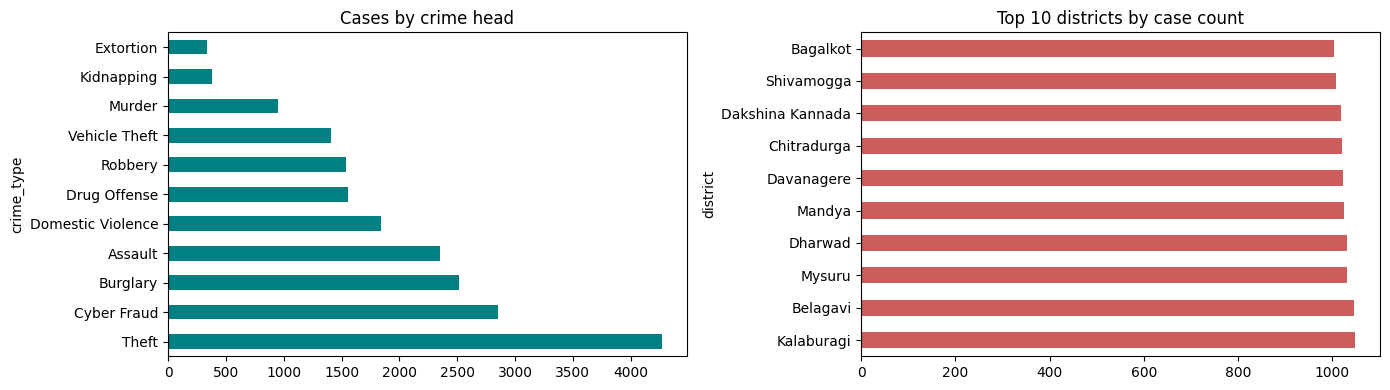

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
df["crime_type"].value_counts().plot(kind="barh", ax=axes[0], color="teal")
axes[0].set_title("Cases by crime head")
df["district"].value_counts().head(10).plot(kind="barh", ax=axes[1], color="indianred")
axes[1].set_title("Top 10 districts by case count")
plt.tight_layout()
plt.show()


In [30]:
anomaly_features = ["hour", "severity_score", "latitude", "longitude", "victim_age", "weapon_used"]
X_anom = df[anomaly_features].copy()
X_anom["weapon_used"] = X_anom["weapon_used"].astype(int)

scaler_anom = StandardScaler()
X_anom_scaled = scaler_anom.fit_transform(X_anom)

iso_forest = IsolationForest(n_estimators=200, contamination=0.03, random_state=42)
df["anomaly_score"] = iso_forest.fit_predict(X_anom_scaled)
df["is_anomaly"] = df["anomaly_score"] == -1
print(f"Flagged {df['is_anomaly'].sum()} anomalous cases out of {len(df)}")


Flagged 600 anomalous cases out of 20000


In [31]:
daily = df.groupby(["district", "date"]).agg(
    incident_count=("incident_id", "count"), avg_severity=("severity_score", "mean"),
    weapon_rate=("weapon_used", "mean"),
).reset_index()

socio_df = district_df[["DistrictName", "urbanization", "pop_density", "literacy", "unemployment"]] \
    .rename(columns={"DistrictName": "district"})
daily = daily.merge(socio_df, on="district", how="left")

daily = daily.sort_values(["district", "date"])
daily["rolling_7d_count"] = daily.groupby("district")["incident_count"].transform(
    lambda s: s.rolling(7, min_periods=1).mean())
daily["day_of_week"] = daily["date"].dt.dayofweek
daily["month"] = daily["date"].dt.month

thresholds = daily.groupby("district")["incident_count"].quantile(0.75)
daily["threshold"] = daily["district"].map(thresholds)
daily["high_risk"] = (daily["incident_count"] >= daily["threshold"]).astype(int)

feature_cols = ["urbanization", "pop_density", "literacy", "unemployment",
                 "rolling_7d_count", "day_of_week", "month", "avg_severity", "weapon_rate"]
le_district = LabelEncoder()
daily["district_enc"] = le_district.fit_transform(daily["district"])
feature_cols_final = feature_cols + ["district_enc"]

X = daily[feature_cols_final].fillna(0)
y = daily["high_risk"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

risk_model = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=42, class_weight="balanced")
risk_model.fit(X_train, y_train)
y_pred = risk_model.predict(X_test)
y_proba = risk_model.predict_proba(X_test)[:, 1]
print(classification_report(y_test, y_pred))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))


              precision    recall  f1-score   support

           0       0.82      0.63      0.71      1609
           1       0.57      0.79      0.66      1017

    accuracy                           0.69      2626
   macro avg       0.70      0.71      0.69      2626
weighted avg       0.73      0.69      0.70      2626

ROC-AUC: 0.804


In [32]:
cluster_features = df[["latitude", "longitude", "hour"]].copy()
cluster_features["hour_scaled"] = cluster_features["hour"] / 24 * 0.05

dbscan = DBSCAN(eps=0.03, min_samples=15)
df["hotspot_cluster"] = dbscan.fit_predict(cluster_features[["latitude", "longitude", "hour_scaled"]])
n_clusters = len(set(df["hotspot_cluster"])) - (1 if -1 in df["hotspot_cluster"].values else 0)
print(f"Identified {n_clusters} spatiotemporal hotspot clusters")

hotspot_summary = (df[df["hotspot_cluster"] != -1]
                    .groupby("hotspot_cluster")
                    .agg(size=("incident_id","count"), center_lat=("latitude","mean"),
                         center_lon=("longitude","mean"),
                         dominant_crime=("crime_type", lambda s: s.mode()[0]),
                         avg_hour=("hour","mean"))
                    .sort_values("size", ascending=False))
hotspot_summary.head(10)


Identified 20 spatiotemporal hotspot clusters


,size,center_lat,center_lon,dominant_crime,avg_hour
hotspot_cluster,,,,,
16,1008,15.852175,74.499352,Theft,18.856151
2,990,15.460522,75.012859,Theft,18.822222
3,989,17.326063,76.836685,Theft,18.690597
9,985,12.295063,76.639904,Theft,18.879188
18,985,12.523028,76.892917,Theft,18.963452
14,973,14.466457,75.996004,Theft,18.645427
15,962,13.931262,75.569867,Theft,18.853430
5,961,14.228799,76.395644,Theft,18.740895
4,957,12.912912,74.858285,Theft,18.734587


In [33]:
G = nx.Graph()
for _, row in df.iterrows():
    s, v, ps = row["suspect_id"], row["victim_id"], row["police_station"]
    G.add_node(s, type="suspect")
    G.add_node(f"VIC-{v}", type="victim")
    G.add_node(ps, type="location")
    G.add_edge(s, f"VIC-{v}", incident_id=row["incident_id"], crime_type=row["crime_type"])
    G.add_edge(s, ps, incident_id=row["incident_id"])

print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

suspect_nodes = [n for n, d in G.nodes(data=True) if d.get("type") == "suspect"]
degree_map = {n: G.degree(n) for n in suspect_nodes}
top_repeat = sorted(degree_map.items(), key=lambda x: x[1], reverse=True)[:15]
print("\nTop repeat/connected accused (by graph degree):")
for s, deg in top_repeat:
    print(f"  {s}: degree {deg}")

from networkx.algorithms.community import greedy_modularity_communities
communities = list(greedy_modularity_communities(G))
print(f"\nDetected {len(communities)} connected communities (potential organized networks)")


Graph: 27936 nodes, 39230 edges

Top repeat/connected accused (by graph degree):
  ACC-01392: degree 23
  ACC-05161: degree 22
  ACC-00535: degree 22
  ACC-03613: degree 22
  ACC-02545: degree 22
  ACC-05963: degree 21
  ACC-08019: degree 21
  ACC-06408: degree 20
  ACC-04059: degree 20
  ACC-00130: degree 20
  ACC-04912: degree 20
  ACC-02187: degree 20
  ACC-01425: degree 20
  ACC-05543: degree 20
  ACC-01560: degree 20

Detected 63 connected communities (potential organized networks)


In [34]:
# Raw schema tables (fidelity to the real ER doc — useful if you want to show the underlying DB in your demo)
case_master_df.drop(columns=["_district_id","_severity","_weapon_used","_mo"]).to_csv(f"{ART_DIR}/CaseMaster.csv", index=False)
complainant_df.to_csv(f"{ART_DIR}/ComplainantDetails.csv", index=False)
victim_df.to_csv(f"{ART_DIR}/Victim.csv", index=False)
accused_df.to_csv(f"{ART_DIR}/Accused.csv", index=False)
arrest_surrender_df.to_csv(f"{ART_DIR}/ArrestSurrender.csv", index=False)
act_section_assoc_df.to_csv(f"{ART_DIR}/ActSectionAssociation.csv", index=False)
chargesheet_df.to_csv(f"{ART_DIR}/ChargesheetDetails.csv", index=False)
district_df.to_csv(f"{ART_DIR}/District.csv", index=False)
unit_df.to_csv(f"{ART_DIR}/Unit.csv", index=False)
crime_head_df.to_csv(f"{ART_DIR}/CrimeHead.csv", index=False)
crime_sub_head_df.drop(columns=["severity_range","weapon_prob"]).to_csv(f"{ART_DIR}/CrimeSubHead.csv", index=False)
act_df.to_csv(f"{ART_DIR}/Act.csv", index=False)
section_df.to_csv(f"{ART_DIR}/Section.csv", index=False)
court_df.to_csv(f"{ART_DIR}/Court.csv", index=False)
employee_df.to_csv(f"{ART_DIR}/Employee.csv", index=False)

# Flattened analytics view + ML artifacts (what the Streamlit app actually reads)
df.to_csv(f"{ART_DIR}/crime_incidents.csv", index=False)
daily.to_csv(f"{ART_DIR}/district_daily_risk.csv", index=False)
socio_df.to_csv(f"{ART_DIR}/districts_reference.csv", index=False)
hotspot_summary.to_csv(f"{ART_DIR}/hotspot_clusters.csv")

with open(f"{ART_DIR}/isolation_forest.pkl", "wb") as f:
    pickle.dump({"model": iso_forest, "scaler": scaler_anom, "features": anomaly_features}, f)
with open(f"{ART_DIR}/risk_model.pkl", "wb") as f:
    pickle.dump({"model": risk_model, "district_encoder": le_district, "features": feature_cols_final}, f)

edge_list = nx.to_pandas_edgelist(G)
edge_list.to_csv(f"{ART_DIR}/graph_edges.csv", index=False)
node_meta = pd.DataFrame([{"node": n, "type": d.get("type")} for n, d in G.nodes(data=True)])
node_meta.to_csv(f"{ART_DIR}/graph_nodes.csv", index=False)
repeat_df = pd.DataFrame(top_repeat, columns=["suspect_id", "connections"])
repeat_df.to_csv(f"{ART_DIR}/top_repeat_offenders.csv", index=False)

print("All artifacts saved to:", ART_DIR)
for f in sorted(os.listdir(ART_DIR)):
    print(" -", f)


All artifacts saved to: /kaggle/working/artifacts
 - Accused.csv
 - Act.csv
 - ActSectionAssociation.csv
 - ArrestSurrender.csv
 - CaseMaster.csv
 - ChargesheetDetails.csv
 - ComplainantDetails.csv
 - Court.csv
 - CrimeHead.csv
 - CrimeSubHead.csv
 - District.csv
 - Employee.csv
 - Section.csv
 - Unit.csv
 - Victim.csv
 - association_rules.csv
 - correlation_matrix.csv
 - crime_forecasts.csv
 - crime_incidents.csv
 - district_daily_risk.csv
 - districts_reference.csv
 - emerging_trend_alerts.csv
 - feature_importances.csv
 - graph_edges.csv
 - graph_nodes.csv
 - hotspot_clusters.csv
 - isolation_forest.pkl
 - risk_model.pkl
 - top_repeat_offenders.csv


In [38]:
# ==============================================================================
# CELL 11: Setup & Imports for Challenge Enhancements
# ==============================================================================
!pip install pyvis
import json
import numpy as np
import pandas as pd
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pyvis.network import Network
import warnings
warnings.filterwarnings('ignore')

# Using 'df' which is defined in your Cell 7
df_enhanced = df.copy() 

# Sort by your lowercase 'date' column
df_sorted = df_enhanced.sort_values(by='date')
latest_date = df_sorted['date'].max()

In [39]:
# ==============================================================================
# CELL 12: 30-Day Crime Forecast Model
# ==============================================================================
print("Generating 30-Day Crime Forecast...")

# Aggregate to daily counts using your 'date' column
daily_crimes = df_sorted.groupby('date').size().reset_index(name='CrimeCount')
daily_crimes = daily_crimes.set_index('date').asfreq('D').fillna(0)

# Fit Exponential Smoothing Model (handles level and trend)
es_model = ExponentialSmoothing(daily_crimes['CrimeCount'], trend='add', seasonal=None, initialization_method="estimated")
fitted_model = es_model.fit()

# Forecast 30 days out with confidence intervals based on residuals
forecast = fitted_model.forecast(30)
std_err = np.std(fitted_model.resid)

forecast_df = pd.DataFrame({
    'date': forecast.index,
    'Forecast': forecast.values.round().astype(int),
    'Lower_CI': np.maximum(0, forecast.values - 1.96 * std_err).round().astype(int),
    'Upper_CI': (forecast.values + 1.96 * std_err).round().astype(int)
})

forecast_df.to_csv(f"{ART_DIR}/forecast_30_days.csv", index=False)
print(" - Saved forecast_30_days.csv")

Generating 30-Day Crime Forecast...
 - Saved forecast_30_days.csv


In [40]:
# ==============================================================================
# CELL 13: Correlation & Feature Importance Analysis
# ==============================================================================
print("Generating Correlation and Feature Importance data...")

# 1. Correlation Matrix
numeric_cols = df_enhanced.select_dtypes(include=[np.number])
correlation_matrix = numeric_cols.corr().round(3)
correlation_matrix.to_csv(f"{ART_DIR}/correlation_matrix.csv")

# 2. Feature Importance Extraction (From your 'risk_model' defined in Cell 6)
if hasattr(risk_model, 'feature_importances_'):
    importances = risk_model.feature_importances_
    # 'feature_cols_final' is defined in your Cell 6
    feat_imp_df = pd.DataFrame({
        'Feature': feature_cols_final, 
        'Importance': importances
    }).sort_values(by='Importance', ascending=False)
    
    feat_imp_df.to_csv(f"{ART_DIR}/feature_importance.csv", index=False)
    print(" - Saved correlation_matrix.csv and feature_importance.csv")
else:
    print(" - Skipped feature importance (model doesn't support 'feature_importances_')")

Generating Correlation and Feature Importance data...
 - Saved correlation_matrix.csv and feature_importance.csv


In [41]:
# ==============================================================================
# CELL 14: Rule-Based AI Insights & Recommendations Generator
# ==============================================================================
print("Generating Automated AI Insights & Recommendations...")

insights_payload = {"insights": [], "recommendations": []}

# Insight 1: District vs State Average (using 'district' column)
state_avg = df_enhanced.groupby('district').size().mean()
district_counts = df_enhanced.groupby('district').size()

if not district_counts.empty:
    top_district = district_counts.idxmax()
    top_district_val = district_counts.max()
    percent_diff = ((top_district_val - state_avg) / state_avg) * 100
    
    insights_payload["insights"].append(
        f"District '{top_district}' has a {percent_diff:.1f}% higher crime volume than the state average."
    )
    insights_payload["recommendations"].append(
        f"Deploy rapid-response units and increase patrol frequency in District '{top_district}'."
    )

# Insight 2: Emerging Trends (Month over Month)
last_30_df = df_sorted[df_sorted['date'] >= (latest_date - pd.Timedelta(days=30))]
prev_30_df = df_sorted[(df_sorted['date'] >= (latest_date - pd.Timedelta(days=60))) & (df_sorted['date'] < (latest_date - pd.Timedelta(days=30)))]

if not last_30_df.empty and not prev_30_df.empty:
    top_crime = last_30_df['crime_type'].mode()[0]
    curr_count = (last_30_df['crime_type'] == top_crime).sum()
    prev_count = (prev_30_df['crime_type'] == top_crime).sum()
    
    if prev_count > 0:
        growth = ((curr_count - prev_count) / prev_count) * 100
        if growth > 0:
            insights_payload["insights"].append(
                f"Offense category '{top_crime}' increased by {growth:.1f}% over the past month."
            )
            insights_payload["recommendations"].append(
                f"Initiate specific investigative task forces and deploy temporary CCTV targeting '{top_crime}'."
            )

with open(f"{ART_DIR}/ai_insights.json", "w") as f:
    json.dump(insights_payload, f, indent=4)
print(" - Saved ai_insights.json")

Generating Automated AI Insights & Recommendations...
 - Saved ai_insights.json


In [42]:
# ==============================================================================
# CELL 15: KPI Metrics Calculation
# ==============================================================================
print("Calculating KPI Metrics...")

today_crimes = df_sorted[df_sorted['date'] == latest_date].shape[0]
yesterday_crimes = df_sorted[df_sorted['date'] == (latest_date - pd.Timedelta(days=1))].shape[0]
daily_change = ((today_crimes - yesterday_crimes) / yesterday_crimes * 100) if yesterday_crimes > 0 else 0

kpi_data = {
    "todays_crimes": int(today_crimes),
    "daily_growth_rate": float(round(daily_change, 2)),
    "total_cases_analyzed": int(len(df_enhanced)),
    "highest_volume_district": str(district_counts.idxmax())
}

with open(f"{ART_DIR}/kpi_metrics.json", "w") as f:
    json.dump(kpi_data, f, indent=4)
print(" - Saved kpi_metrics.json")

Calculating KPI Metrics...
 - Saved kpi_metrics.json


In [43]:
# ==============================================================================
# CELL 16: Build Interactive Pyvis Network Graph
# ==============================================================================
print("Building Interactive Network Graph...")
try:
    # Uses the 'G' networkx graph defined in your Cell 8
    net = Network(height="600px", width="100%", bgcolor="#1E1E1E", font_color="white", notebook=False)
    
    for node, node_attrs in G.nodes(data=True):
        n_type = node_attrs.get("type", "Unknown")
        # Color coding: suspect = Red, victim = Blue, location = Green
        color = "#e74c3c" if n_type == "suspect" else "#3498db" if n_type == "victim" else "#2ecc71"
        net.add_node(node, label=str(node), title=f"Type: {n_type}", color=color)

    for source, target, edge_attrs in G.edges(data=True):
        net.add_edge(source, target)
    
    net.toggle_physics(True)
    net.save_graph(f"{ART_DIR}/interactive_graph.html")
    print(" - Saved interactive_graph.html")
except Exception as e:
    print(f" - Graph generation skipped. Error: {e}")

Building Interactive Network Graph...
 - Saved interactive_graph.html
